# Варіаційний автоенкодер (VAE) для MNIST

VAE навчається **кодувати** зображення у компактне латентне представлення та **декодувати** їх назад. На відміну від звичайного автоенкодера, латентний простір регуляризується так, щоб відповідати нормальному розподілу, що дозволяє **генерувати нові зображення** шляхом вибірки з цього розподілу.

## Варіант 7 — AE vs. VAE (роль KL-регуляризації)

### Контекст

Якщо задати `beta=0`, ми повністю прибираємо доданок KL-дивергенції, і VAE перетворюється на звичайний **автоенкодер (AE)**. AE все ще може добре відновлювати зображення, але його латентний простір не має структури: нічого не змушує його бути гладким або відповідати відомому розподілу. Через це генерація (вибірка з апріорного розподілу) зазвичай різко погіршується.

### Завдання

1. **Навчіть звичайний автоенкодер**, встановивши `beta=0` (5 епох, усі інші гіперпараметри ті самі).
2. **Навчіть стандартний VAE** з `beta=1.0` (5 епох, ті самі гіперпараметри).
3. Для **обох** моделей отримайте:
   - Реконструкції тих самих 8 тестових зображень.
   - 16 згенерованих зразків шляхом вибірки `z ~ N(0, I)` і декодування.
   - PCA-візуалізацію латентного простору.
   - Криві навчання.
4. Порівняйте результати поруч.

### Що здати

- **Графіки**: реконструкції, згенеровані зразки, латентний простір і криві навчання для AE та VAE.
- **Письмове пояснення** (3–5 речень): Яка модель краще реконструює? Яка краще генерує зразки і чому? Яким є латентний простір без KL-регуляризації, і як це пояснює різницю в якості генерації?

### Підказки

- AE (`beta=0`) зазвичай має меншу втрату реконструкції, але дуже погано генерує зразки.
- Подивіться на scatter-графіки латентного простору – латентні коди AE часто групуються в малих, відокремлених областях далеко від початку координат.
- Вибірка `z ~ N(0, I)` може взагалі не потрапляти в області, де лежать латентні коди AE, тому результат декодування буде схожий на шум.


# **Звичайний автоенкодер (beta=0)**

In [1]:
from importlib.metadata import version

pkgs = ["torch",
        "torchvision",
        "numpy",
        "matplotlib"
       ]
for p in pkgs:
    print(f"{p}: {version(p)}")

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
numpy: 2.0.2
matplotlib: 3.10.0


In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [3]:
import random
import numpy as np

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(61)

## Архітектура моделі

VAE складається з трьох ключових частин:
1. **Енкодер** — відображає вхідне зображення у два вектори: середнє (`mu`) та логарифм дисперсії (`logvar`) апроксимаційного апостеріорного розподілу $q(z \mid x)$.
2. **Reparameterization trick** – виконує вибірку
   `z = mu + sigma * eps`, де `eps ~ N(0, I)`.
   Це робить операцію вибірки (семплювання) диференційовною, що дозволяє виконувати backpropagation (зворотне поширення похибки) через неї.
3. **Декодер** — відображає латентний вектор `z` у реконструйоване зображення.

In [4]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, image_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder: image -> shared hidden layers -> mu and logvar
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent z -> reconstructed image pixels in [0, 1]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        # Reparameterization trick: z = mu + sigma * eps, where eps ~ N(0, I)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(mu)
        return mu + sigma * eps

    def decode(self, z: torch.Tensor):
        # Reshape flat output back to image: (batch, channels, height, width)
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(image_dim=28*28, hidden_dim=256, latent_dim=12).to(device)
model

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=12, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=12, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

## Набір даних (dataset)

**MNIST**: 70 000 зображень рукописних цифр у відтінках сірого (28×28 пікселів).

`transforms.ToTensor()` перетворює значення пікселів із цілих чисел у діапазоні [0, 255] на числа з плаваючою комою в діапазоні [0, 1].

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BATCH_SIZE = 256

transform = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

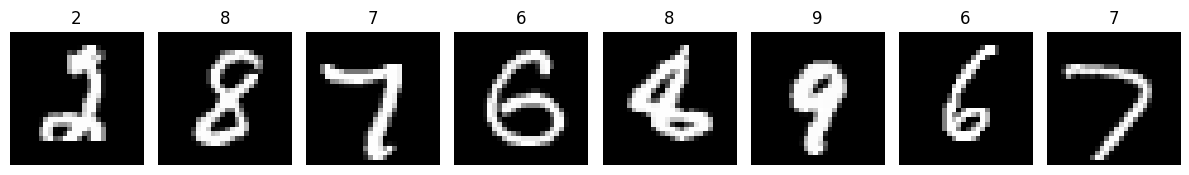

In [6]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, images[:8], labels[:8]):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(int(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Функція втрат і навчання

Функція втрат (loss function) VAE складається з двох доданків:

- **Втрата реконструкції** (бінарна крос-ентропія) – стимулює декодер відтворювати зображення, максимально близьке до вхідного.
- **KL-дивергенція** — наближає розподіл енкодера $q(z \mid x)$ до апріорного розподілу $N(0, I)$, забезпечуючи гладкий і неперервний латентний простір.

Параметр `beta` визначає компроміс між цими складовими: більше `beta` → сильніша регуляризація (гладший латентний простір, але більш розмиті реконструкції).

In [7]:
from torch.nn import functional as F
from tqdm import tqdm

def vae_loss(x, x_recon, mu, logvar, beta=1.0):
    x_flat = x.view(x.size(0), -1)
    x_recon_flat = x_recon.view(x_recon.size(0), -1)

    # Reconstruction loss: how well the decoder output matches the input
    recon = F.binary_cross_entropy(x_recon_flat, x_flat, reduction="sum") / x.size(0)

    # KL divergence: regularizes the latent space toward N(0, I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    loss = recon + beta * kl
    return loss, recon.item(), kl.item()

def train_one_epoch(model, loader, optimizer, beta, epoch, epochs):
    model.train()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_recon, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon
        total_kl += kl
        n += 1
    return total_loss / n, total_recon / n, total_kl / n

@torch.no_grad()
def evaluate(model, loader, beta):
    model.eval()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_recon, mu, logvar, beta)
        total_loss += loss.item()
        total_recon += recon
        total_kl += kl
        n += 1
    return total_loss / n, total_recon / n, total_kl / n

In [8]:
EPOCHS = 5
LEARNING_RATE = 1e-3
BETA = 0

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train": [], "val": []}

for epoch in range(EPOCHS):
    t_loss, t_recon, t_kl = train_one_epoch(model, train_loader, optimizer, BETA, epoch, EPOCHS)
    v_loss, v_recon, v_kl = evaluate(model, test_loader, BETA)
    history["train"].append((t_loss, t_recon, t_kl))
    history["val"].append((v_loss, v_recon, v_kl))
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={t_loss:.3f} | val_loss={v_loss:.3f} | "
        f"val_recon={v_recon:.3f} | val_kl={v_kl:.3f}"
    )

Epoch 1/5 | train_loss=195.568 | val_loss=140.378 | val_recon=140.378 | val_kl=94.510


Epoch 2/5 | train_loss=120.628 | val_loss=106.454 | val_recon=106.454 | val_kl=171.431


Epoch 3/5 | train_loss=101.314 | val_loss=94.857 | val_recon=94.857 | val_kl=216.817


Epoch 4/5 | train_loss=93.016 | val_loss=89.484 | val_recon=89.484 | val_kl=242.245


Epoch 5/5 | train_loss=88.611 | val_loss=86.129 | val_recon=86.129 | val_kl=254.493


## Криві навчання

Криві навчання показують зміну значень функції втрат протягом епох:

- **Загальна втрата** — сума втрати реконструкції та KL-дивергенції.
- **Втрата реконструкції** — відображає, наскільки точно модель відтворює вхідні зображення.
- **KL-дивергенція** — показує, наскільки латентний розподіл наближається до апріорного $N(0, I)$.

Аналіз цих кривих дозволяє зрозуміти динаміку навчання та баланс між якістю реконструкції й регуляризацією латентного простору.

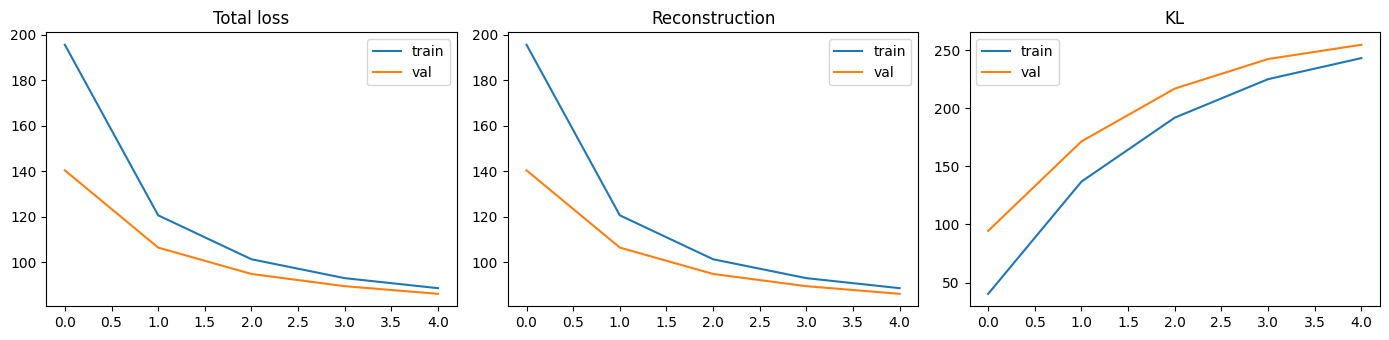

In [9]:
def plot_history(history):
    train = list(zip(*history["train"]))  # [[losses], [recons], [kls]]
    val   = list(zip(*history["val"]))
    titles = ["Total loss", "Reconstruction", "KL"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, t, v, title in zip(axes, train, val, titles):
        ax.plot(t, label="train")
        ax.plot(v, label="val")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

## Реконструкції

Верхній ряд: оригінальні тестові зображення. Нижній ряд: реконструкції, отримані AE після кодування та декодування.

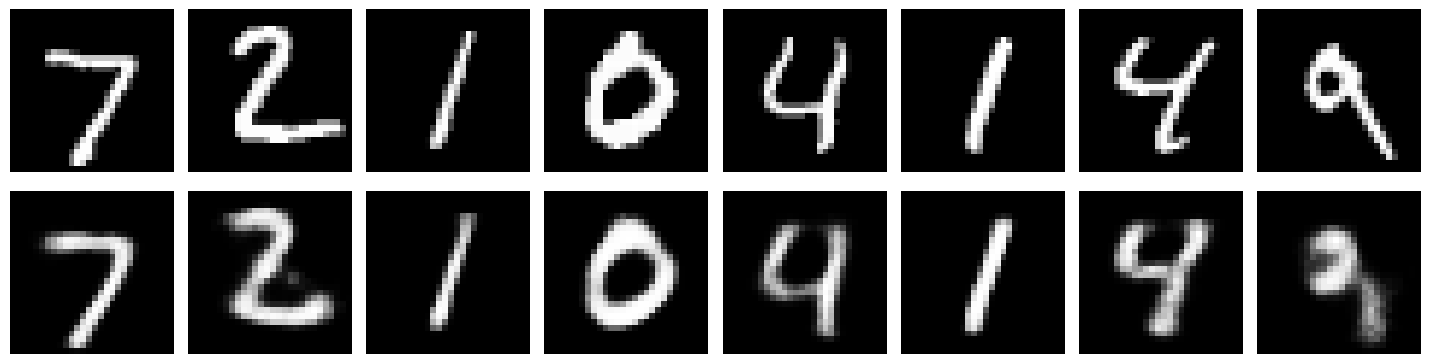

In [10]:
@torch.no_grad()
def show_reconstructions(model, data_loader, n: int = 8):
    model.eval()
    x, _ = next(iter(data_loader))
    x = x[:n].to(device)
    x_recon, _, _ = model(x)
    x = x.cpu()
    x_recon = x_recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(0), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_recon[i].squeeze(0), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Recon")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=8)

## Генерація нових цифр

Вибірка випадкових точок з апріорного розподілу $N(0, I)$.

Оскільки KL-регуляризація формує гладкий латентний простір, близькі точки в ньому дають подібні за виглядом цифри.

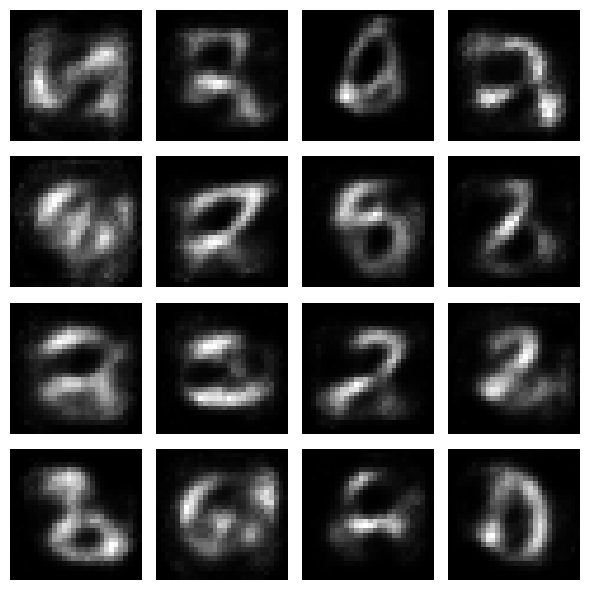

In [11]:
@torch.no_grad()
def sample_from_prior(model, n=16):
    """Generate new assets by sampling z ~ N(0, I) and decoding."""
    model.eval()
    z = torch.randn(n, model.latent_dim, device=device)
    x_gen = model.decode(z).cpu()

    k = int(n**0.5)
    fig, axes = plt.subplots(k, k, figsize=(6, 6))
    for idx, ax in enumerate(axes.flat):
        ax.imshow(x_gen[idx, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_from_prior(model, n=16)

## Візуалізація латентного простору

Проєкція 12-вимірних латентних кодів у двовимірний простір за допомогою PCA.

Добре навчений VAE має формувати кластери цифр із плавними переходами між ними.

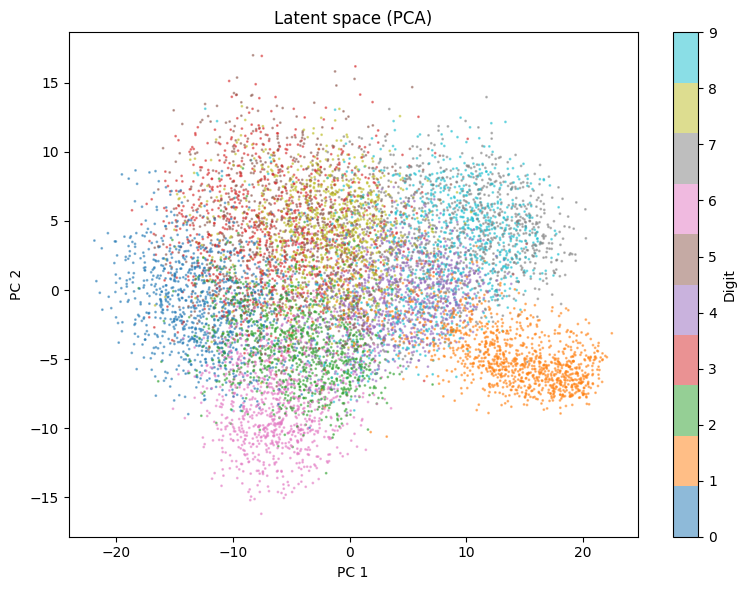

In [12]:
@torch.no_grad()
def plot_latent_space(model, loader):
    """Encode the test set and project latent codes to 2D with PCA."""
    model.eval()
    zs, ys = [], []
    for x, y in loader:
        mu, _ = model.encode(x.to(device))
        zs.append(mu.cpu())
        ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys).numpy()

    # PCA: center the data, then project onto the top-2 principal components
    zs_centered = zs - zs.mean(dim=0)
    _, _, V = torch.pca_lowrank(zs_centered, q=2, center=False)
    zs_2d = (zs_centered @ V).numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(zs_2d[:, 0], zs_2d[:, 1], c=ys, cmap="tab10", s=1, alpha=0.5)
    plt.colorbar(scatter, label="Digit")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title("Latent space (PCA)")
    plt.tight_layout()
    plt.show()

plot_latent_space(model, test_loader)

# **Стандартний VAE (beta=1.0)**

In [13]:
from importlib.metadata import version

pkgs = ["torch",
        "torchvision",
        "numpy",
        "matplotlib"
       ]
for p in pkgs:
    print(f"{p}: {version(p)}")

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
numpy: 2.0.2
matplotlib: 3.10.0


In [14]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


In [15]:
import random
import numpy as np

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(61)

## Архітектура моделі

VAE складається з трьох ключових частин:
1. **Енкодер** — відображає вхідне зображення у два вектори: середнє (`mu`) та логарифм дисперсії (`logvar`) апроксимаційного апостеріорного розподілу $q(z \mid x)$.
2. **Reparameterization trick** – виконує вибірку
   `z = mu + sigma * eps`, де `eps ~ N(0, I)`.
   Це робить операцію вибірки (семплювання) диференційовною, що дозволяє виконувати backpropagation (зворотне поширення похибки) через неї.
3. **Декодер** — відображає латентний вектор `z` у реконструйоване зображення.

In [16]:
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, image_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()

        self.latent_dim = latent_dim

        # Encoder: image -> shared hidden layers -> mu and logvar
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent z -> reconstructed image pixels in [0, 1]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        # Reparameterization trick: z = mu + sigma * eps, where eps ~ N(0, I)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(mu)
        return mu + sigma * eps

    def decode(self, z: torch.Tensor):
        # Reshape flat output back to image: (batch, channels, height, width)
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(image_dim=28*28, hidden_dim=256, latent_dim=12).to(device)
model

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=12, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=12, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

## Набір даних (dataset)

**MNIST**: 70 000 зображень рукописних цифр у відтінках сірого (28×28 пікселів).

`transforms.ToTensor()` перетворює значення пікселів із цілих чисел у діапазоні [0, 255] на числа з плаваючою комою в діапазоні [0, 1].

In [17]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BATCH_SIZE = 256

transform = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

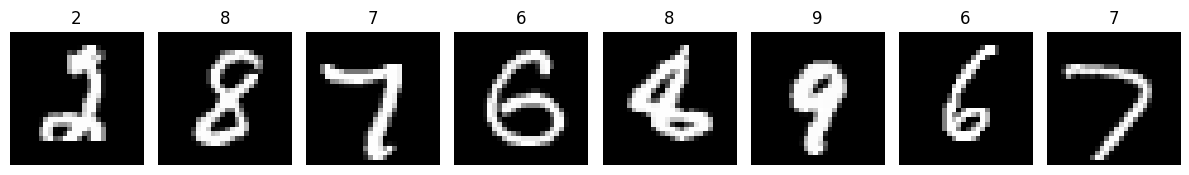

In [18]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, images[:8], labels[:8]):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(int(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Функція втрат і навчання

Функція втрат (loss function) VAE складається з двох доданків:

- **Втрата реконструкції** (бінарна крос-ентропія) – стимулює декодер відтворювати зображення, максимально близьке до вхідного.
- **KL-дивергенція** — наближає розподіл енкодера $q(z \mid x)$ до апріорного розподілу $N(0, I)$, забезпечуючи гладкий і неперервний латентний простір.

Параметр `beta` визначає компроміс між цими складовими: більше `beta` → сильніша регуляризація (гладший латентний простір, але більш розмиті реконструкції).

In [19]:
from torch.nn import functional as F
from tqdm import tqdm

def vae_loss(x, x_recon, mu, logvar, beta=1.0):
    x_flat = x.view(x.size(0), -1)
    x_recon_flat = x_recon.view(x_recon.size(0), -1)

    # Reconstruction loss: how well the decoder output matches the input
    recon = F.binary_cross_entropy(x_recon_flat, x_flat, reduction="sum") / x.size(0)

    # KL divergence: regularizes the latent space toward N(0, I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    loss = recon + beta * kl
    return loss, recon.item(), kl.item()

def train_one_epoch(model, loader, optimizer, beta, epoch, epochs):
    model.train()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_recon, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon
        total_kl += kl
        n += 1
    return total_loss / n, total_recon / n, total_kl / n

@torch.no_grad()
def evaluate(model, loader, beta):
    model.eval()
    total_loss, total_recon, total_kl, n = 0.0, 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device)
        x_recon, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x, x_recon, mu, logvar, beta)
        total_loss += loss.item()
        total_recon += recon
        total_kl += kl
        n += 1
    return total_loss / n, total_recon / n, total_kl / n

In [20]:
EPOCHS = 5
LEARNING_RATE = 1e-3
BETA = 1.0

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train": [], "val": []}

for epoch in range(EPOCHS):
    t_loss, t_recon, t_kl = train_one_epoch(model, train_loader, optimizer, BETA, epoch, EPOCHS)
    v_loss, v_recon, v_kl = evaluate(model, test_loader, BETA)
    history["train"].append((t_loss, t_recon, t_kl))
    history["val"].append((v_loss, v_recon, v_kl))
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={t_loss:.3f} | val_loss={v_loss:.3f} | "
        f"val_recon={v_recon:.3f} | val_kl={v_kl:.3f}"
    )

Epoch 1/5 | train_loss=206.215 | val_loss=169.864 | val_recon=162.408 | val_kl=7.456


Epoch 2/5 | train_loss=152.336 | val_loss=137.549 | val_recon=125.426 | val_kl=12.123


Epoch 3/5 | train_loss=132.611 | val_loss=126.560 | val_recon=112.793 | val_kl=13.768


Epoch 4/5 | train_loss=124.258 | val_loss=119.874 | val_recon=104.615 | val_kl=15.260


Epoch 5/5 | train_loss=119.557 | val_loss=117.298 | val_recon=101.039 | val_kl=16.259


## Криві навчання

Криві навчання показують зміну значень функції втрат протягом епох:

- **Загальна втрата** — сума втрати реконструкції та KL-дивергенції.
- **Втрата реконструкції** — відображає, наскільки точно модель відтворює вхідні зображення.
- **KL-дивергенція** — показує, наскільки латентний розподіл наближається до апріорного $N(0, I)$.

Аналіз цих кривих дозволяє зрозуміти динаміку навчання та баланс між якістю реконструкції й регуляризацією латентного простору.

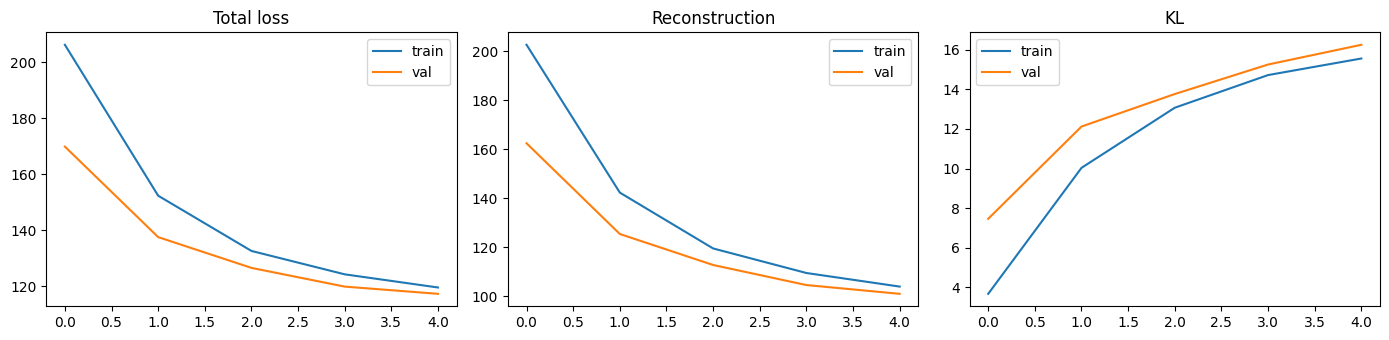

In [21]:
def plot_history(history):
    train = list(zip(*history["train"]))  # [[losses], [recons], [kls]]
    val   = list(zip(*history["val"]))
    titles = ["Total loss", "Reconstruction", "KL"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, t, v, title in zip(axes, train, val, titles):
        ax.plot(t, label="train")
        ax.plot(v, label="val")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

## Реконструкції

Верхній ряд: оригінальні тестові зображення. Нижній ряд: реконструкції, отримані VAE після кодування та декодування.

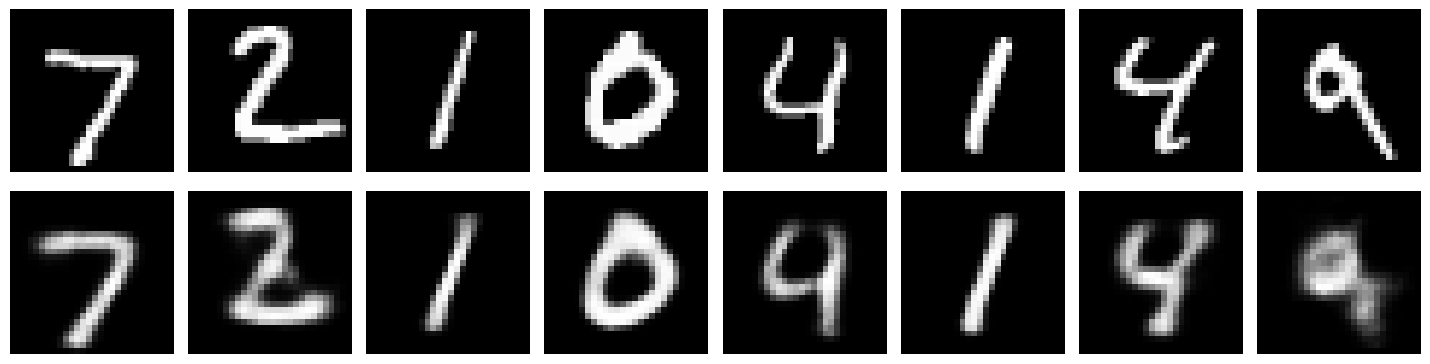

In [22]:
@torch.no_grad()
def show_reconstructions(model, data_loader, n: int = 8):
    model.eval()
    x, _ = next(iter(data_loader))
    x = x[:n].to(device)
    x_recon, _, _ = model(x)
    x = x.cpu()
    x_recon = x_recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(0), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_recon[i].squeeze(0), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Recon")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, n=8)

## Генерація нових цифр

Вибірка випадкових точок з апріорного розподілу $N(0, I)$.

Оскільки KL-регуляризація формує гладкий латентний простір, близькі точки в ньому дають подібні за виглядом цифри.

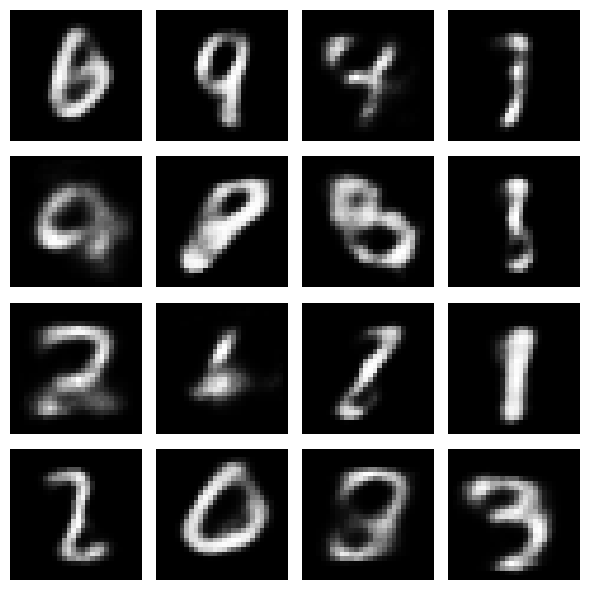

In [23]:
@torch.no_grad()
def sample_from_prior(model, n=16):
    """Generate new assets by sampling z ~ N(0, I) and decoding."""
    model.eval()
    z = torch.randn(n, model.latent_dim, device=device)
    x_gen = model.decode(z).cpu()

    k = int(n**0.5)
    fig, axes = plt.subplots(k, k, figsize=(6, 6))
    for idx, ax in enumerate(axes.flat):
        ax.imshow(x_gen[idx, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_from_prior(model, n=16)

## Візуалізація латентного простору

Проєкція 12-вимірних латентних кодів у двовимірний простір за допомогою PCA.

Добре навчений VAE має формувати кластери цифр із плавними переходами між ними.

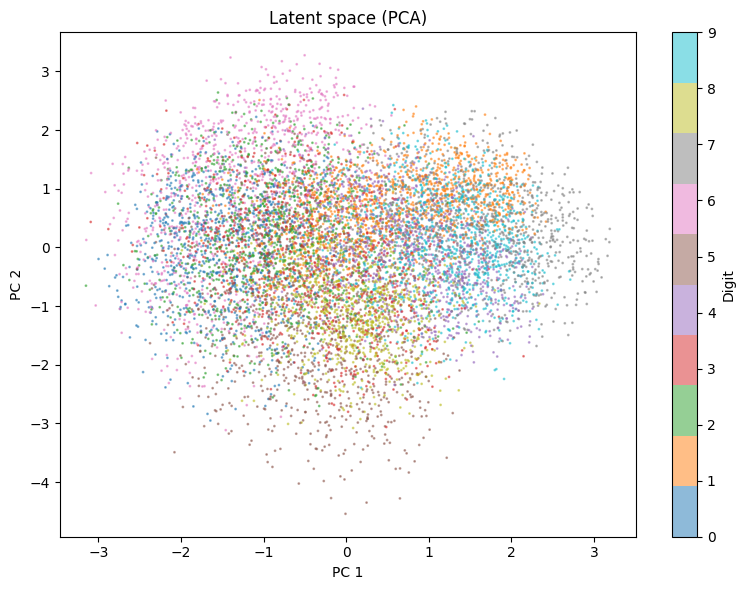

In [24]:
@torch.no_grad()
def plot_latent_space(model, loader):
    """Encode the test set and project latent codes to 2D with PCA."""
    model.eval()
    zs, ys = [], []
    for x, y in loader:
        mu, _ = model.encode(x.to(device))
        zs.append(mu.cpu())
        ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys).numpy()

    # PCA: center the data, then project onto the top-2 principal components
    zs_centered = zs - zs.mean(dim=0)
    _, _, V = torch.pca_lowrank(zs_centered, q=2, center=False)
    zs_2d = (zs_centered @ V).numpy()

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(zs_2d[:, 0], zs_2d[:, 1], c=ys, cmap="tab10", s=1, alpha=0.5)
    plt.colorbar(scatter, label="Digit")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title("Latent space (PCA)")
    plt.tight_layout()
    plt.show()

plot_latent_space(model, test_loader)

# **Пояснення:**

Звичайний автоенкодер (β = 0) краще реконструює зображення, оскільки оптимізує лише помилку реконструкції та не має додаткових обмежень на латентний простір. Variational Autoencoder (β = 1) може трохи гірше відтворювати конкретні зображення, але краще генерує нові зразки. Це відбувається тому, що KL-регуляризація змушує латентний простір наближатися до нормального розподілу, що робить його більш впорядкованим і придатним для генерації. Без KL-регуляризації латентний простір стає нерівномірним і фрагментованим, тому випадкова вибірка з нормального розподілу дає гірші результати генерації.